# 🎯 Modelo de Uplift con T-Learner

## Objetivo

Construir un modelo de uplift para estimar el efecto incremental del email sobre cada cliente.

A diferencia de un modelo de clasificación tradicional, aquí no buscamos predecir únicamente la conversión, sino estimar cuánto cambia la probabilidad de conversión cuando un cliente recibe el tratamiento.

## Enfoque

Se utilizará un enfoque **T-Learner**, que consiste en entrenar:

- un modelo para clientes tratados
- un modelo para clientes no tratados

Luego, el uplift estimado se calcula como:

**uplift estimado = probabilidad predicha con tratamiento - probabilidad predicha sin tratamiento**

## Resultado esperado

Este enfoque permitirá priorizar clientes en función de su impacto incremental esperado.

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
ruta = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\hillstrom.csv"

df = pd.read_csv(ruta)

df = df.reset_index().rename(columns={'index': 'id_cliente'})

In [25]:
df['tratamiento'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)
df['target'] = df['conversion']

In [26]:
columnas_excluir = ['segment', 'conversion', 'visit', 'spend', 'target']
columnas_features = [col for col in df.columns if col not in columnas_excluir]

X = df[columnas_features].copy()
y = df['target'].copy()
w = df['tratamiento'].copy()

In [27]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.3,
    random_state=42,
    stratify=df[['tratamiento', 'target']].astype(str).agg('_'.join, axis=1)
)

In [28]:
categoricas = X_train.select_dtypes(include=['object']).columns.tolist()
numericas = X_train.select_dtypes(exclude=['object']).columns.tolist()

print("Variables categóricas:", categoricas)
print("Variables numéricas:", numericas)

Variables categóricas: ['history_segment', 'zip_code', 'channel']
Variables numéricas: ['id_cliente', 'recency', 'history', 'mens', 'womens', 'newbie', 'tratamiento']


In [29]:
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ('num', 'passthrough', numericas)
    ]
)

In [30]:
X_train_tratados = X_train[w_train == 1].copy()
y_train_tratados = y_train[w_train == 1].copy()

X_train_control = X_train[w_train == 0].copy()
y_train_control = y_train[w_train == 0].copy()

print("Observaciones tratadas:", X_train_tratados.shape[0])
print("Observaciones control:", X_train_control.shape[0])

Observaciones tratadas: 29886
Observaciones control: 14914


In [31]:
modelo_tratados = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

modelo_tratados.fit(X_train_tratados, y_train_tratados)

[LightGBM] [Info] Number of positive: 319, number of negative: 29567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 555
[LightGBM] [Info] Number of data points in the train set: 29886, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010674 -> initscore=-4.529223
[LightGBM] [Info] Start training from score -4.529223
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
modelo_control = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

modelo_control.fit(X_train_control, y_train_control)

[LightGBM] [Info] Number of positive: 85, number of negative: 14829
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 555
[LightGBM] [Info] Number of data points in the train set: 14914, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005699 -> initscore=-5.161689
[LightGBM] [Info] Start training from score -5.161689
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [33]:
prob_tratado = modelo_tratados.predict_proba(X_test)[:, 1]
prob_control = modelo_control.predict_proba(X_test)[:, 1]

uplift_estimado = prob_tratado - prob_control

In [34]:
df_uplift = X_test.copy()

df_uplift['id_cliente'] = df.loc[X_test.index, 'id_cliente'].values
df_uplift['target'] = y_test.values
df_uplift['tratamiento'] = w_test.values
df_uplift['prob_tratado'] = prob_tratado
df_uplift['prob_control'] = prob_control
df_uplift['uplift_estimado'] = uplift_estimado

df_uplift.head()

,id_cliente,recency,history_segment,history,mens,womens,zip_code,newbie,channel,tratamiento,target,prob_tratado,prob_control,uplift_estimado
19808,19808,9,2) $100 - $200,173.32,1,0,Rural,0,Phone,0,0,0.005197,0.005724,-0.000528
56629,56629,3,2) $100 - $200,100.66,0,1,Urban,0,Web,0,0,0.005249,0.003125,0.002124
34347,34347,10,3) $200 - $350,236.00,1,0,Urban,1,Phone,1,0,0.002518,0.000401,0.002117
56405,56405,2,1) $0 - $100,97.35,0,1,Urban,0,Web,0,0,0.003805,0.004912,-0.001107
5534,5534,11,1) $0 - $100,29.99,0,1,Surburban,1,Web,0,0,0.001591,0.000277,0.001314


In [35]:
df_uplift['uplift_estimado'].describe().round(2)

count    19200.00
mean         0.01
std          0.02
min         -0.46
25%          0.00
50%          0.00
75%          0.01
max          0.43
Name: uplift_estimado, dtype: float64

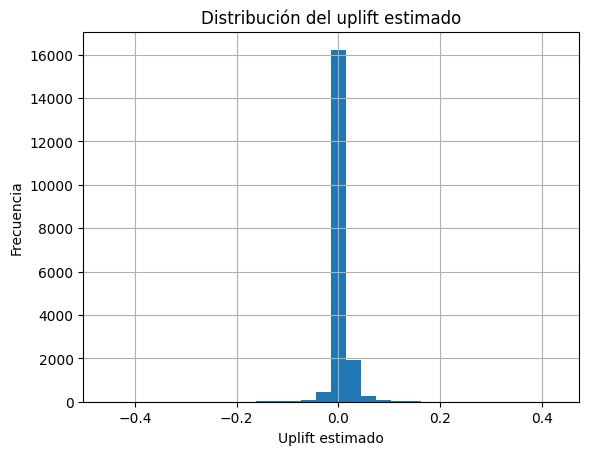

In [36]:
df_uplift['uplift_estimado'].hist(bins=30)
plt.title("Distribución del uplift estimado")
plt.xlabel("Uplift estimado")
plt.ylabel("Frecuencia")
plt.show()

In [37]:
df_uplift_ordenado = df_uplift.sort_values(by='uplift_estimado', ascending=False).copy()

df_uplift_ordenado[['uplift_estimado', 'prob_tratado', 'prob_control']].head(10).round(2)

,uplift_estimado,prob_tratado,prob_control
472,0.43,0.43,0.00
132,0.28,0.28,0.00
710,0.27,0.27,0.00
607,0.25,0.25,0.00
50281,0.23,0.23,0.00
2325,0.23,0.23,0.00
2363,0.23,0.23,0.00
6701,0.19,0.19,0.00
2334,0.19,0.20,0.01
49,0.19,0.19,0.00


In [38]:
df_uplift_ordenado['decil_uplift'] = pd.qcut(
    df_uplift_ordenado['uplift_estimado'],
    q=10,
    labels=False,
    duplicates='drop'
)

df_uplift_ordenado['decil_uplift'] = 10 - df_uplift_ordenado['decil_uplift']

In [39]:
resumen_deciles = df_uplift_ordenado.groupby('decil_uplift').agg(
    clientes=('target', 'count'),
    conversion_promedio=('target', 'mean'),
    uplift_promedio_estimado=('uplift_estimado', 'mean'),
    tasa_tratamiento=('tratamiento', 'mean')
).reset_index()

resumen_deciles.round(2)

,decil_uplift,clientes,conversion_promedio,uplift_promedio_estimado,tasa_tratamiento
0,1,1920,0.01,0.04,0.67
1,2,1920,0.01,0.01,0.67
2,3,1920,0.01,0.01,0.68
3,4,1920,0.01,0.01,0.65
4,5,1920,0.01,0.00,0.66
5,6,1920,0.00,0.00,0.66
6,7,1920,0.01,0.00,0.66
7,8,1920,0.01,0.00,0.67
8,9,1920,0.01,-0.00,0.66
9,10,1920,0.01,-0.02,0.69


In [40]:
def calcular_uplift_observado(grupo):
    conversion_tratados = grupo.loc[grupo['tratamiento'] == 1, 'target'].mean()
    conversion_control = grupo.loc[grupo['tratamiento'] == 0, 'target'].mean()
    return conversion_tratados - conversion_control

uplift_observado_por_decil = (
    df_uplift_ordenado
    .groupby('decil_uplift')
    .apply(calcular_uplift_observado)
    .reset_index(name='uplift_observado')
)

uplift_observado_por_decil.round(2)

,decil_uplift,uplift_observado
0,1,0.01
1,2,0.00
2,3,0.00
3,4,0.00
4,5,0.01
5,6,-0.00
6,7,0.00
7,8,0.00
8,9,0.01
9,10,0.01


In [41]:
resumen_deciles = resumen_deciles.merge(
    uplift_observado_por_decil,
    on='decil_uplift',
    how='left'
)

resumen_deciles.round(2)

,decil_uplift,clientes,conversion_promedio,uplift_promedio_estimado,tasa_tratamiento,uplift_observado
0,1,1920,0.01,0.04,0.67,0.01
1,2,1920,0.01,0.01,0.67,0.00
2,3,1920,0.01,0.01,0.68,0.00
3,4,1920,0.01,0.01,0.65,0.00
4,5,1920,0.01,0.00,0.66,0.01
5,6,1920,0.00,0.00,0.66,-0.00
6,7,1920,0.01,0.00,0.66,0.00
7,8,1920,0.01,0.00,0.67,0.00
8,9,1920,0.01,-0.00,0.66,0.01
9,10,1920,0.01,-0.02,0.69,0.01


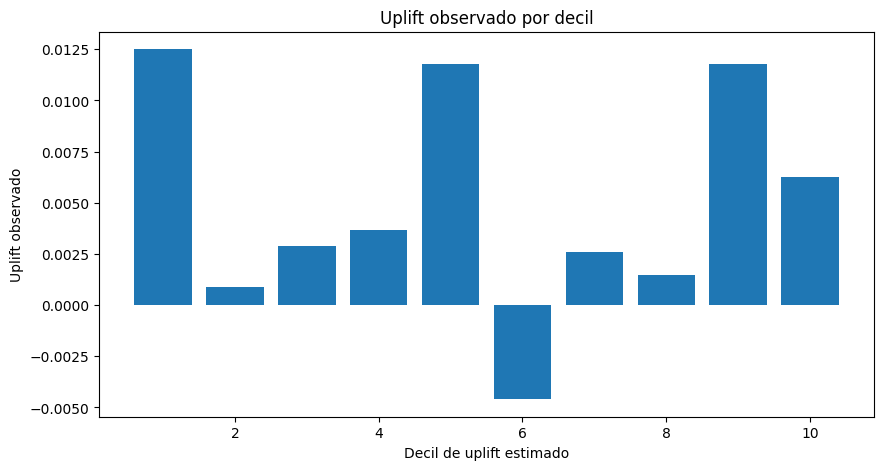

In [42]:
plt.figure(figsize=(10, 5))
plt.bar(resumen_deciles['decil_uplift'], resumen_deciles['uplift_observado'])
plt.title("Uplift observado por decil")
plt.xlabel("Decil de uplift estimado")
plt.ylabel("Uplift observado")
plt.show()

In [43]:
def clasificar_segmento_uplift(uplift):
    if uplift >= 0.03:
        return 'Persuadables'
    elif uplift >= 0:
        return 'Leve respuesta positiva'
    elif uplift >= -0.03:
        return 'Neutros'
    else:
        return 'Posible do not disturb'

df_uplift_ordenado['segmento_uplift'] = df_uplift_ordenado['uplift_estimado'].apply(clasificar_segmento_uplift)

df_uplift_ordenado['segmento_uplift'].value_counts(normalize=True).mul(100).round(2)

segmento_uplift
Leve respuesta positiva    80.64
Neutros                    13.66
Persuadables                4.19
Posible do not disturb      1.52
Name: proportion, dtype: float64

In [44]:
ruta_salida = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\uplift_resultados_test.csv"

df_uplift_ordenado.to_csv(ruta_salida, index=False)

## Resultados del modelo de uplift

- Se estimó el efecto incremental del tratamiento a nivel individual.
- El modelo genera un ranking de clientes según uplift esperado.
- Los deciles superiores concentran clientes con mayor respuesta incremental estimada.
- El uplift observado por decil permite validar si el ranking captura heterogeneidad real en el efecto.

## Conclusión clave

A diferencia del modelo de clasificación tradicional, el T-Learner permite priorizar clientes en función del valor incremental esperado del email.

## Implicación de negocio

Este enfoque permite dejar atrás campañas masivas y avanzar hacia estrategias de targeting más eficientes, enfocadas en clientes persuadables.